In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [11]:
local_csv = "housing.csv"
df = pd.read_csv(local_csv)

print("Dimensiones:", df.shape)
df.head()

Dimensiones: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [12]:
df = df[["latitude", "longitude", "median_income"]]
df.head()

,latitude,longitude,median_income
0,37.88,-122.23,8.3252
1,37.86,-122.22,8.3014
2,37.85,-122.24,7.2574
3,37.85,-122.25,5.6431
4,37.85,-122.25,3.8462


cluster
1    7586
5    5121
0    4165
2    1676
3    1500
4     592
Name: count, dtype: int64


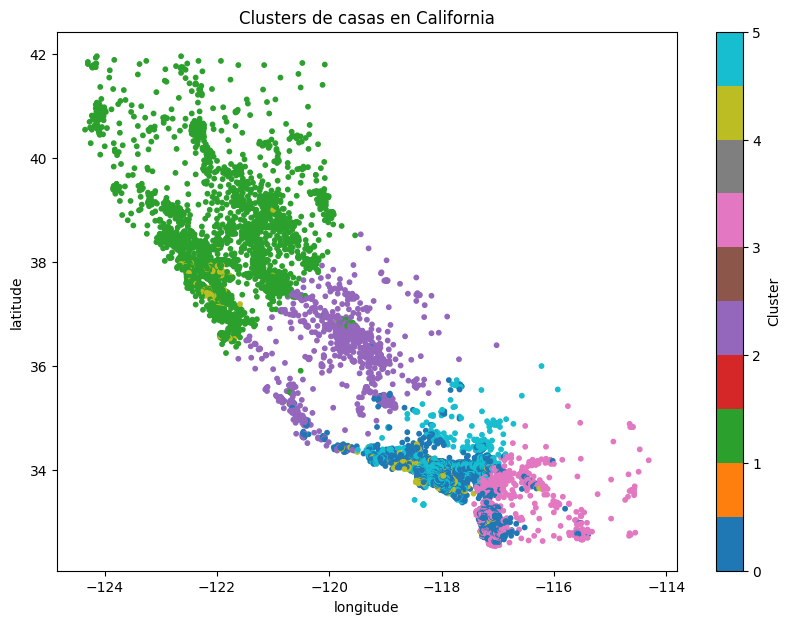

In [15]:
kmeans = KMeans(n_clusters=6, random_state=42)
df["cluster"] = kmeans.fit_predict(df)

print(df["cluster"].value_counts())

plt.figure(figsize=(10,7))
plt.scatter(df["longitude"], df["latitude"], c=df["cluster"], cmap="tab10", s=10)
plt.colorbar(label="Cluster")
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.title("Clusters de casas en California")
plt.show()

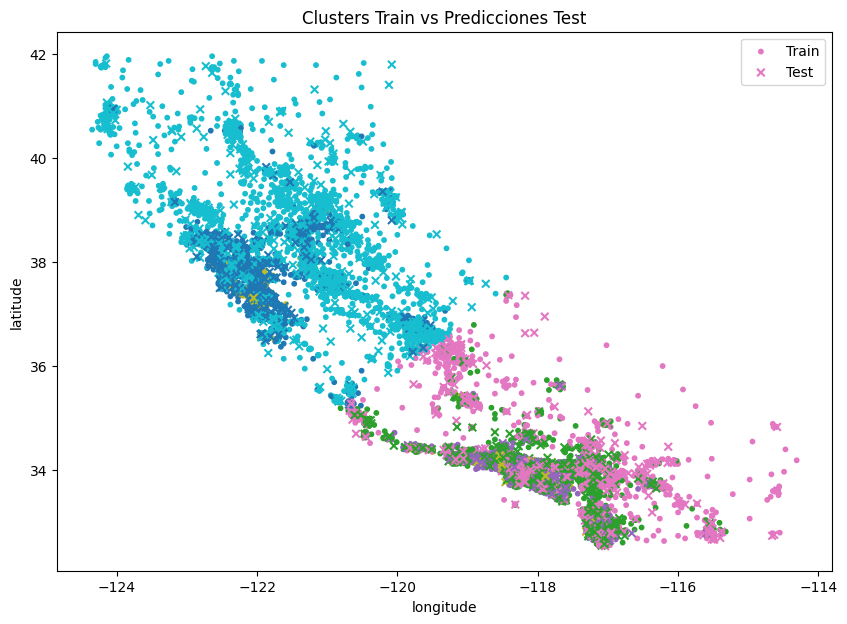

In [ ]:
X = df[["latitude", "longitude", "median_income"]]
y = df["cluster"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

kmeans = KMeans(n_clusters=6, random_state=42)
kmeans.fit(X_train)

y_pred_clusters = kmeans.predict(X_test)

plt.figure(figsize=(10,7))
plt.scatter(X_train["longitude"], X_train["latitude"], c=kmeans.predict(X_train), cmap="tab10", s=10, label="Train")
plt.scatter(X_test["longitude"], X_test["latitude"], c=y_pred_clusters, cmap="tab10", s=30, marker="x", label="Test")
plt.legend()
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.title("Clusters Train vs Predicciones Test")
plt.show()

In [21]:
clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

y_pred_sup = clf.predict(X_test)

print("Clasificación supervisada sobre clusters de KMeans")
print("Accuracy:", accuracy_score(y_test, y_pred_sup))
print(classification_report(y_test, y_pred_sup))

Clasificación supervisada sobre clusters de KMeans
Accuracy: 0.9953972868217055
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       818
           1       1.00      1.00      1.00      1472
           2       0.99      1.00      1.00       338
           3       0.99      0.99      0.99       317
           4       0.98      0.96      0.97       112
           5       1.00      1.00      1.00      1071

    accuracy                           1.00      4128
   macro avg       0.99      0.99      0.99      4128
weighted avg       1.00      1.00      1.00      4128



In [23]:
import joblib

joblib.dump(kmeans, "kmeans_housing.pkl")
joblib.dump(clf, "rf_classifier_housing.pkl")

print("Modelos guardados: kmeans_housing.pkl y rf_classifier_housing.pkl")

Modelos guardados: kmeans_housing.pkl y rf_classifier_housing.pkl
